# Experimenting with CST.csv files to extract env

After downloading all the ctd data we converted them into csv to be able to read the data 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

## Loading Data

We will experiment with the first batch 1

In [3]:
data_path = "../real-data-ctds/csv_output/ctd_batch_1.csv"
data = pd.read_csv(data_path)
data.head()

,date,t1,c1,p1,sal,sv
0,20211003T000000.714Z,9.4602,3.39950,97.318,31.2671,1484.917
1,20211003T000001.733Z,9.4604,3.39950,97.318,31.2670,1484.917
2,20211003T000002.714Z,9.4604,3.39949,97.318,31.2670,1484.917
3,20211003T000003.756Z,9.4604,3.39949,97.318,31.2669,1484.917
4,20211003T000004.713Z,9.4603,3.39949,97.318,31.2670,1484.917


## Data visulaization

In [4]:
data.columns

Index(['date', 't1', 'c1', 'p1', 'sal', 'sv'], dtype='object')

As we see here we have: 

| Column | Meaning      | Unit | Use in Bellhop                          |
| ------ | ------------ | ---- | --------------------------------------- |
| `date` | timestamp    | ISO  | (optional) for labeling                 |
| `t1`   | temperature  | °C   | used to compute sound speed or as check |
| `c1`   | conductivity | S/m  | used to compute salinity if missing     |
| `p1`   | pressure     | dbar | approximates depth (1 dbar ≈ 1 m)       |
| `sal`  | salinity     | PSU  | used to compute or verify sound speed   |
| `sv`   | sound speed  | m/s  | directly used for Bellhop SSP section   |


In [6]:
data.describe()

,t1,c1,p1,sal,sv
count,8.222244e+06,8.222244e+06,8.222244e+06,8.222244e+06,8.222244e+06
mean,9.646189e+00,3.296215e+00,1.037811e+02,3.006365e+01,1.484201e+03
std,9.476776e-01,1.129980e-01,4.905967e+01,1.064791e+00,3.210682e+00
min,7.652700e+00,2.680510e+00,-3.781050e+02,2.314230e+01,1.476021e+03
25%,9.103400e+00,3.225060e+00,4.193900e+01,2.971560e+01,1.481917e+03
50%,9.573400e+00,3.324100e+00,1.123750e+02,3.024180e+01,1.485143e+03
75%,1.019320e+01,3.386420e+00,1.475522e+02,3.057930e+01,1.486287e+03
max,2.059650e+01,3.464390e+00,1.494040e+02,3.131730e+01,1.503678e+03


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8222244 entries, 0 to 8222243
Data columns (total 6 columns):
 #   Column  Dtype  
---  ------  -----  
 0   date    object 
 1   t1      float64
 2   c1      float64
 3   p1      float64
 4   sal     float64
 5   sv      float64
dtypes: float64(5), object(1)
memory usage: 376.4+ MB


# Extracting values for Env file

### Extracting Sound Speed profile

In [4]:
def extract_profile(data):
    df = data
    # Sort by pressure (acts as depth)
    df = df.sort_values('p1')

    # Filter to 0–500 m range
    df = df[(df['p1'] >= 0) & (df['p1'] <= 500)]

    # Bin by 5 m and average sound speed
    df['depth_bin'] = (df['p1'] / 5).round() * 5
    profile = df.groupby('depth_bin')['sv'].mean().reset_index()
    profile.rename(columns={'depth_bin': 'depth', 'sv': 'sound_speed'}, inplace=True)
    return profile

# profile = extract_profile(data)

In [9]:
profile.head()

,depth,sound_speed
0,0.0,1488.362225
1,40.0,1482.827696
2,95.0,1485.145294
3,100.0,1485.160480
4,110.0,1485.967827


We extracted the sound speed for each depth underwater, let's now try to visualize it

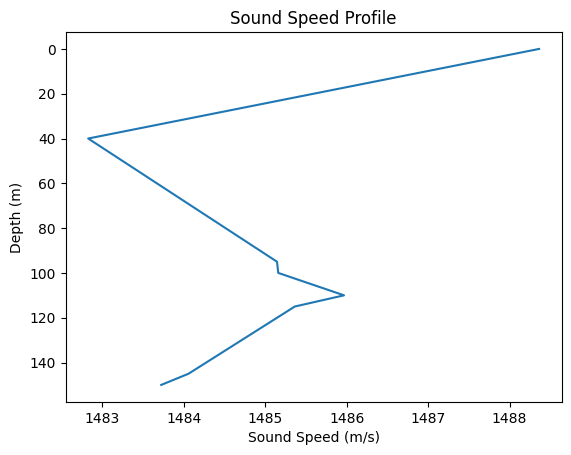

In [12]:
plt.plot(profile['sound_speed'], profile['depth'])
plt.gca().invert_yaxis()
plt.xlabel("Sound Speed (m/s)")
plt.ylabel("Depth (m)")
plt.title("Sound Speed Profile")
plt.show()

## Building and Testing an Enviroment in ARLPY

## Step 1: Create the enviroment directly from `Profile`

In [15]:
import arlpy.uwapm as pm

max_depth = profile['depth'].max()
env = pm.create_env2d(
    depth=max_depth,  # water depth (m)
    soundspeed=profile.values.tolist(),  # [[depth, c], [depth, c], ...]
    bottom_soundspeed=1600,  # for sand bottom
    rx_depth=[10, 50, 100, 150],
    rx_range=[i for i in range(0, 2001, 10)]  # receiver at 0–2000 m
)


### Validate the enviroment

In [16]:
pm.check_env2d(env)
pm.print_env(env)
pm.plot_env(env)
pm.plot_ssp(env)

                name : arlpy
   bottom_absorption : 0.1
      bottom_density : 1600
    bottom_roughness : 0
   bottom_soundspeed : 1600
               depth : 150.0
        depth_interp : linear
           frequency : 25000
           max_angle : 80
           min_angle : -80
              nbeams : 0
            rx_depth : [ 10.  50. 100. 150.]
            rx_range : [   0.   10.   20.   30.   40.   50.   60.   70.   80.   90.  100.  110.
                         120.  130.  140.  150.  160.  170.  180.  190.  200.  210.  220.  230.
                         240.  250.  260.  270.  280.  290.  300.  310.  320.  330.  340.  350.
                         360.  370.  380.  390.  400.  410.  420.  430.  440.  450.  460.  470.
                         480.  490.  500.  510.  520.  530.  540.  550.  560.  570.  580.  590.
                         600.  610.  620.  630.  640.  650.  660.  670.  680.  690.  700.  710.
                         720.  730.  740.  750.  760.  770.  780.  790.  800

The enviroment looks good!

Our Next Step is Loading all the CSV files (4GB) of data

This may break the system if loaded at once so we will load it in batches same way we read the ctd files


# The full CTD Data to enviroment

In [5]:
import glob
import pandas as pd

csv_files = glob.glob("../real-data-ctds/csv_output/ctd_batch_*.csv")
profile = pd.DataFrame()
for file in csv_files:
    batch_data = pd.read_csv(file)
    profile_batch = extract_profile(batch_data)
    profile = pd.concat([profile, profile_batch], ignore_index=True)
    
profile = profile.groupby('depth')['sound_speed'].mean().reset_index()
profile.head()


,depth,sound_speed
0,0.0,1486.549495
1,40.0,1481.760616
2,90.0,1481.232868
3,95.0,1485.081264
4,100.0,1485.148555


### Next steps

As shown above, this data only extends to 100 meters below sea level, but we require a Sound Speed Profile (SSP) down to 500m. To solve this, we will generate the extended SSP based on the available data using a custom script.

This script automatically extends the profile to the target depth. First, it calculates sound speed from the measured temperature and salinity data. Since our measurements are shallow, the script then creates a physically plausible extension for the deeper water (100-500m). It does this by applying a smooth, gradual increase in sound speed, a common characteristic of deeper ocean layers, and blends it with the measured data to avoid any discontinuities. The final output is a complete, 5-meter resolution SSP from 0 to 500 meters, ready for acoustic modeling.


In [ ]:
# save as extend_ssp_salish.py and run in your local environment
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# try to import optional libs
try:
    import gsw
    has_gsw = True
except Exception:
    has_gsw = False

try:
    import xarray as xr
    has_xarray = True
except Exception:
    has_xarray = False

# -------------------------
# PARAMETERS (edit)
ctd_csv = "/Users/abdullahabdelaizz/Myfiles/Underwater/bellhop_output/assets/subset_batch_1.csv"    # your local CSV subset with columns: p1 (pressure dbar ~ m), t1 (temp C), sal (PSU), sv (opt)
target_max_depth = 500        # meters
blend_window = 30             # meters for blending when merging with climatology
# -------------------------

# 1) load a subset profile (make sure we're handling single cast / single time)
df = pd.read_csv(ctd_csv)
# If your file contains many timestamps, select a single timestamp or average by depth first.
# For example, if there is a 'date' column, pick the first date:
if 'date' in df.columns:
    first_date = df['date'].iloc[0]
    df = df[df['date'] == first_date].copy()

# Clean & sort
df = df[['p1','t1','sal','sv']].dropna(subset=['p1']).sort_values('p1')
df = df[(df['p1'] >= 0) & (df['p1'] <= target_max_depth)]
df = df.drop_duplicates(subset='p1', keep='first')

# If the CSV has many repeated samplings at many times, you might need:
# df = df.groupby('p1').mean().reset_index()

meas_max = df['p1'].max()
print("Measured max depth:", meas_max)

# 2) compute sound speed using gsw if possible, else fallback to Mackenzie formula
if has_gsw:
    # gsw expects Absolute Salinity (SA) and Conservative Temperature (CT)
    # If salinity is Practical Salinity (PSU), convert using gsw.SA_from_SP (requires lon/lat),
    # but for approximate sound speed we can use gsw.sound_speed(SA,CT,p) using SA ~= SP (approx).
    # Here we'll approximate SA = sal, CT = t1
    s = df['sal'].values
    t = df['t1'].values
    p = df['p1'].values
    ss = gsw.sound_speed(s, t, p)   # approx if SA~=SP
    df['sv_calc'] = ss
    print("Computed sound speed using gsw.")
else:
    # Mackenzie approximation (less accurate but acceptable)
    T = df['t1'].values; S = df['sal'].values; D = df['p1'].values
    # Mackenzie 1981 (approx)
    c = (1448.96 + 4.591*T - 5.304e-2*T**2 + 2.374e-4*T**3 +
         1.340*(S-35) + 1.630e-2*D + 1.675e-7*D**2 -
         1.025e-2*T*(S-35) - 7.139e-13*T*D**3)
    df['sv_calc'] = c
    print("Computed sound speed using Mackenzie formula (fallback).")

# Use measured 'sv' if available but prefer computed for consistency
if 'sv' in df.columns and df['sv'].notna().sum() > 0:
    # compare measured vs computed
    err = np.nanmean(np.abs(df['sv'].values - df['sv_calc'].values))
    print(f"Mean abs diff measured vs computed sv: {err:.3f} m/s")
    # prefer computed to keep consistent chain
    df['sv_use'] = df['sv_calc']
else:
    df['sv_use'] = df['sv_calc']

# 3) Prepare the measured profile (binned by 5m)
df['depth_bin'] = (df['p1'] / 5).round() * 5
profile = df.groupby('depth_bin')['sv_use'].mean().reset_index().rename(columns={'depth_bin':'depth','sv_use':'sound_speed'})
profile = profile.sort_values('depth').reset_index(drop=True)

# If measured top is already >= target_max_depth, we are done
if profile['depth'].max() >= target_max_depth:
    profile_extended = profile[profile['depth'] <= target_max_depth].copy()
else:
    # 4) attempt to fetch a climatology deep profile (World Ocean Atlas / local model)
    climatology_profile = None
    if has_xarray:
        try:
            # Try using NOAA WOA or a local netCDF if you have it. Online OPeNDAP access may be blocked.
            # This block attempts to open a WOA dataset via OPeNDAP (may fail if offline).
            # For reliability, keep this optional - if it fails we fall back to extrapolation below.
            ds = xr.open_dataset("https://www.ncei.noaa.gov/thredds/dodsC/woa/WOA18/DATA/temperature/netcdf/decav/0.25/woa18_decav_t00_04.nc")
            # NOTE: this is an example; real variable names and indexes depend on dataset; retrieving a local WOA file is recommended.
            # If it works, build a simple deep profile at the location nearest your cast (lat/lon needed).
            climatology_profile = None
        except Exception:
            climatology_profile = None

    # 5) fallback: build a blended extrapolation
    # We'll create depths from last_measured+5 to target_max_depth every 5 m
    last_depth = profile['depth'].max()
    last_speed = profile['sound_speed'].iloc[-1]
    # choose a plausible deep gradient (m/s per meter). Typical small increase ~0.005 - 0.02 m/s per meter.
    grad = 0.008  # tune this: 0.008 m/s per m -> 4 m/s increase over 500m
    extra_depths = np.arange(last_depth + 5, target_max_depth + 1, 5)
    extra_speeds = last_speed + grad * (extra_depths - last_depth)
    extra_df = pd.DataFrame({'depth': extra_depths, 'sound_speed': extra_speeds})

    # Smoothly blend in a small transition window
    # Create a linear weight from 0 (at last_depth) to 1 (at last_depth + blend_window)
    blend = blend_window
    trans_depths = np.arange(last_depth, last_depth + blend + 1, 1)
    # create transition points between measured and extrapolated
    # We'll resample measured/extra to 1m resolution for blending then downsample to 5m
    meas_interp = np.interp(trans_depths, profile['depth'], profile['sound_speed'])
    extra_interp = np.interp(trans_depths, np.concatenate(([last_depth], extra_depths)),
                             np.concatenate(([last_speed], extra_speeds)))
    w = np.clip((trans_depths - last_depth) / blend, 0, 1)
    blended_interp = (1 - w) * meas_interp + w * extra_interp

    # now combine: measured up to last_depth, blended transition, then rest of extra_df beyond last_depth+blend
    blended_df = pd.DataFrame({'depth': trans_depths, 'sound_speed': blended_interp})
    beyond = extra_df[extra_df['depth'] > last_depth + blend]
    profile_extended = pd.concat([
        profile[profile['depth'] < last_depth],         # measured up to before last depth
        pd.DataFrame({'depth':[last_depth],'sound_speed':[last_speed]}),
        blended_df,
        beyond
    ], ignore_index=True)

# 6) downsample to 5m grid to keep tidy
grid_depths = np.arange(0, target_max_depth + 1, 5)
interp_sounds = np.interp(grid_depths, profile_extended['depth'], profile_extended['sound_speed'])
final_profile = pd.DataFrame({'depth': grid_depths, 'sound_speed': interp_sounds})

# 7) quick plot
plt.figure(figsize=(4,8))
plt.plot(final_profile['sound_speed'], final_profile['depth'], '-o', markersize=3)
plt.gca().invert_yaxis()
plt.xlabel("Sound speed (m/s)")
plt.ylabel("Depth (m)")
plt.title("Extended SSP 0-{} m".format(target_max_depth))
plt.grid(True)
plt.show()

# 8) Save profile to CSV for use in Bellhop (or create env in arlpy)
final_profile.to_csv("./assets/extended_ssp_0_{}m_v2.csv".format(target_max_depth), index=False)
print("Saved: extended_ssp_0_{}m_v2.csv".format(target_max_depth))


#  Stage 2A: Build ARLPY Environment from Extended SSP

                name : arlpy
   bottom_absorption : 0.8
      bottom_density : 1800
    bottom_roughness : 0
   bottom_soundspeed : 1600
               depth : 500
        depth_interp : linear
           frequency : 1500
           max_angle : 80
           min_angle : -80
              nbeams : 0
            rx_depth : [  5.          48.88888889  92.77777778 136.66666667 180.55555556
                        224.44444444 268.33333333 312.22222222 356.11111111 400.        ]
            rx_range : [   0.           10.05025126   20.10050251   30.15075377   40.20100503
                          50.25125628   60.30150754   70.35175879   80.40201005   90.45226131
                         100.50251256  110.55276382  120.60301508  130.65326633  140.70351759
                         150.75376884  160.8040201   170.85427136  180.90452261  190.95477387
                         201.00502513  211.05527638  221.10552764  231.15577889  241.20603015
                         251.25628141  261.30653266

Impulse response length: 155965 samples


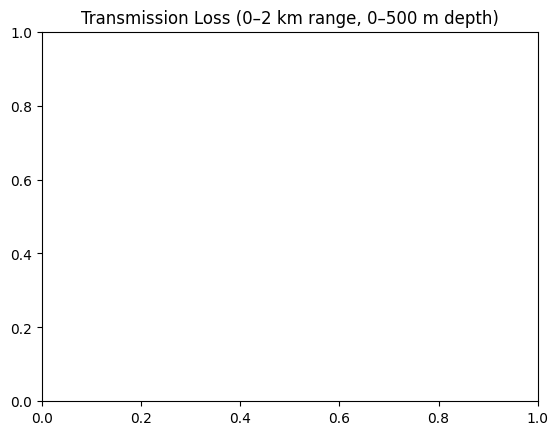

In [13]:
# -------------------------------------------------------
#  Stage 2A: Build ARLPY Environment from Extended SSP
# -------------------------------------------------------
import arlpy.uwapm as pm
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# --- 1) Load your extended SSP file (from Stage 1 / previous step)
data_path = "/Users/abdullahabdelaizz/Myfiles/Underwater/bellhop_output/assets/extended_ssp_0_500m_v2.csv"
profile = pd.read_csv(data_path)   

# --- 2) Create ARLPY environment
env = pm.create_env2d(
    depth=500,                                    
    soundspeed=profile.values.tolist(),           # [[depth, c], ...]
    bottom_soundspeed=1600,                       # sand bottom (~1.6 km/s)
    bottom_density=1800,                          # kg/m³ (optional, default reasonable)
    bottom_absorption=0.8,                               # attenuation (dB/λ)
    rx_depth=np.linspace(5, 400, 10),             # receivers at 5–400 m (10 hydrophones)
    rx_range=np.linspace(0, 2000, 200),           # range 0–2 km (200 points)
    frequency=1500                                    # frequency (Hz)
)

# --- 3) Check and visualize environment
pm.check_env2d(env)
pm.print_env(env)
pm.plot_env(env)
pm.plot_ssp(env)

# --- 4) Compute transmission loss
tloss = pm.compute_transmission_loss(env, mode='incoherent')
pm.plot_transmission_loss(tloss, env=env, width=1000)
plt.title("Transmission Loss (0–2 km range, 0–500 m depth)")

# --- 5) Compute eigenrays and visualize
rays = pm.compute_eigenrays(env)
pm.plot_rays(rays, env=env, width=1000)

# --- 6) Compute arrivals and impulse response
arrivals = pm.compute_arrivals(env)
pm.plot_arrivals(arrivals)

ir = pm.arrivals_to_impulse_response(arrivals, fs=48000)
print(f"Impulse response length: {len(ir)} samples")

# --- 7) Save impulse response and metadata (optional)
np.save("./assets/ir_salish_env.npy", ir)

# optional: save transmission loss as CSV for later ML use
tloss_mag = np.abs(tloss)**2
np.savetxt("./assets/tloss_salish_env.csv", tloss_mag, delimiter=',')


# Convolve source signal with Impulse Response

In [3]:
from scipy.signal import fftconvolve
import soundfile as sf
import numpy as np

source_signal = "../assets/000000_submarine.wav"
impulse_response = "../assets/ir_salish_env.npy"

output = "../assets/submarine_A_patrol_propagated.wav"
source, fs = sf.read(source_signal)
ir = np.load(impulse_response)

# Convolve (complex result)
propagated = fftconvolve(source, ir, mode='full')

# Convert to real-valued audio
propagated_real = np.real(propagated)  # or np.abs(propagated)

# Normalize to safe audio range
propagated_real /= np.max(np.abs(propagated_real) + 1e-12)

sf.write(output, propagated_real.astype(np.float32), fs)
print("✅ Saved propagated audio successfully.")

✅ Saved propagated audio successfully.


Generating Waveform plot...


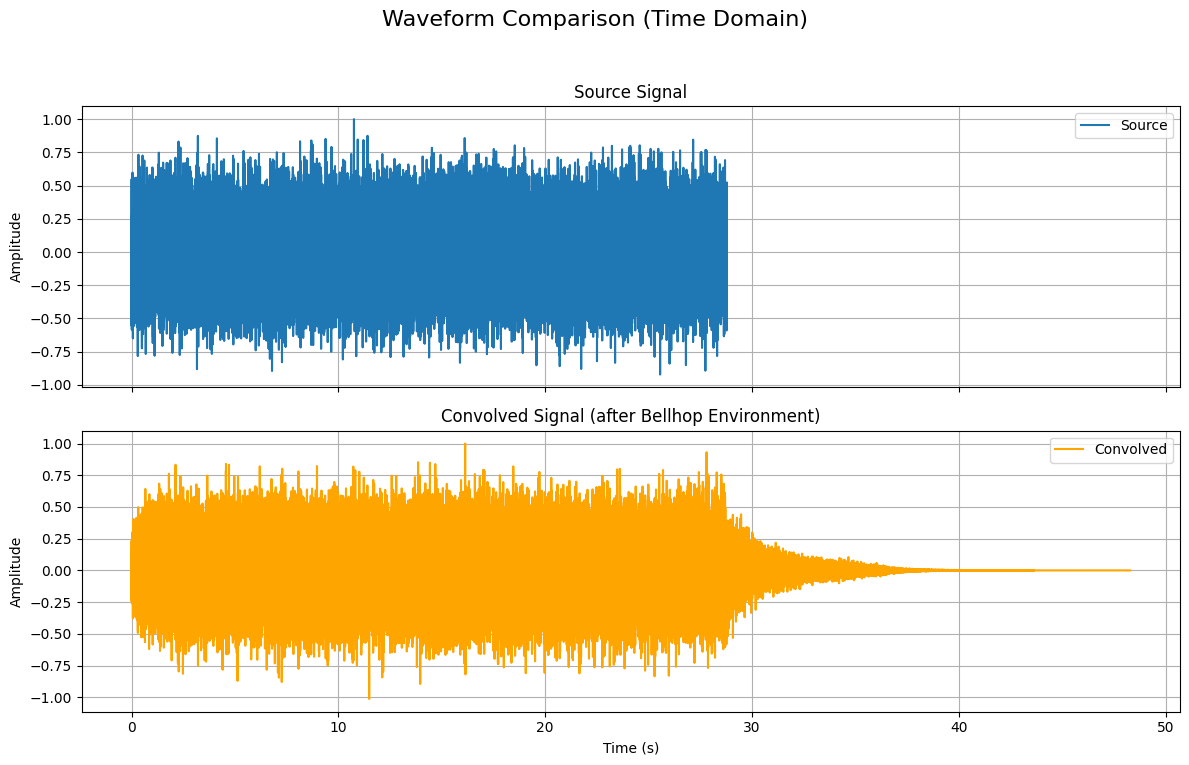

Generating Spectrogram plot...


/var/folders/f7/d9r2cdsn7rjfqldbrf0y09dc0000gn/T/ipykernel_26911/1702669466.py:91: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


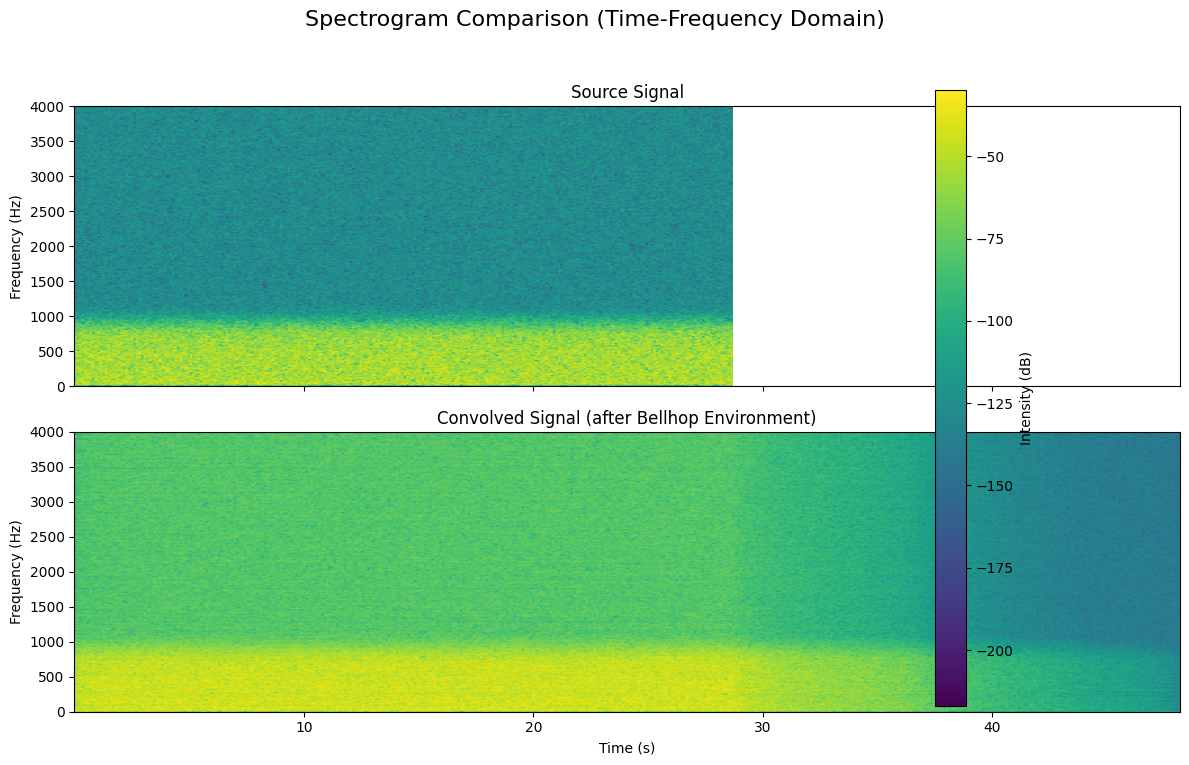

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.io import wavfile

# --- 1. Load Your WAV Files ---
# Replace with the correct paths to your files
SOURCE_FILE = source_signal
CONVOLVED_FILE = output

try:
    # Read the source signal
    sr_source, data_source = wavfile.read(SOURCE_FILE)
    
    # Read the convolved signal
    sr_convolved, data_convolved = wavfile.read(CONVOLVED_FILE)

    # Ensure sample rates are the same
    if sr_source != sr_convolved:
        print(f"Warning: Sample rates differ! ({sr_source} Hz vs {sr_convolved} Hz)")
        # Simple resampling (if needed, but for plotting it might be fine)
        # Note: This is a very basic example.
        # For analysis, you should ensure they are properly aligned.
        
    # --- 2. Prepare Data for Plotting ---
    
    # Function to handle stereo/mono and normalize to [-1, 1]
    def prepare_audio(data):
        # If stereo, just take the left channel
        if data.ndim > 1:
            data = data[:, 0]
        # Normalize to floating point between -1 and 1
        return data / np.max(np.abs(data))

    source_norm = prepare_audio(data_source)
    convolved_norm = prepare_audio(data_convolved)

    # Create time axes for each signal
    time_source = np.arange(len(source_norm)) / float(sr_source)
    time_convolved = np.arange(len(convolved_norm)) / float(sr_convolved)

    # --- 3. Plot 1: Waveform Comparison (Time Domain) ---
    print("Generating Waveform plot...")
    fig1, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
    
    fig1.suptitle('Waveform Comparison (Time Domain)', fontsize=16)

    # Plot Source Signal
    ax1.plot(time_source, source_norm, label='Source')
    ax1.set_title('Source Signal')
    ax1.set_ylabel('Amplitude')
    ax1.grid(True)
    ax1.legend(loc='upper right')

    # Plot Convolved Signal
    ax2.plot(time_convolved, convolved_norm, label='Convolved', color='orange')
    ax2.set_title('Convolved Signal (after Bellhop Environment)')
    ax2.set_xlabel('Time (s)')
    ax2.set_ylabel('Amplitude')
    ax2.grid(True)
    ax2.legend(loc='upper right')
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    # --- 4. Plot 2: Spectrogram Comparison (Time-Frequency Domain) ---
    print("Generating Spectrogram plot...")
    fig2, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True, sharey=True)
    
    fig2.suptitle('Spectrogram Comparison (Time-Frequency Domain)', fontsize=16)
    
    NFFT = 1024  # Number of data points used in each block for the FFT

    # Plot Source Spectrogram
    Pxx_source, freqs_source, bins_source, im_source = ax1.specgram(
        source_norm, NFFT=NFFT, Fs=sr_source, cmap='viridis'
    )
    ax1.set_title('Source Signal')
    ax1.set_ylabel('Frequency (Hz)')
    
    # Plot Convolved Spectrogram
    Pxx_convolved, freqs_convolved, bins_convolved, im_convolved = ax2.specgram(
        convolved_norm, NFFT=NFFT, Fs=sr_convolved, cmap='viridis'
    )
    ax2.set_title('Convolved Signal (after Bellhop Environment)')
    ax2.set_xlabel('Time (s)')
    ax2.set_ylabel('Frequency (Hz)')

    # Add a color bar
    fig2.colorbar(im_convolved, ax=[ax1, ax2], label='Intensity (dB)')
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

except FileNotFoundError as e:
    print(f"Error: {e}")
    print("Please make sure 'source_signal.wav' and 'convolved_signal.wav' are in the same directory.")
except Exception as e:
    print(f"An error occurred: {e}")

Successfully loaded '../assets/ir_salish_env.npy'
Data shape: (155965,)
Data type (dtype): complex128
Data dimensions (ndim): 1
Min value: (-0.03235913748889072-0.007217755395875737j)
Max value: (0.05608363200469409-0.08217631948017425j)
Data is 1D. Plotting as a line graph...


/Users/abdullahabdelaizz/miniconda3/envs/underwater/lib/python3.12/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/abdullahabdelaizz/miniconda3/envs/underwater/lib/python3.12/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


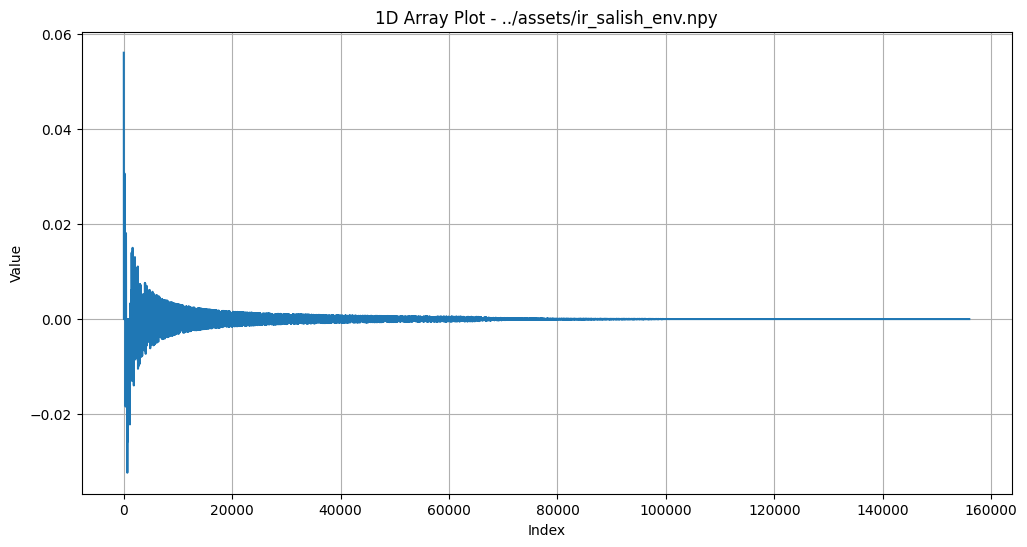

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# --- CONFIGURATION ---
# Change this to the exact name of your .npy file
FILE_NAME = impulse_response
# ---------------------

def visualize_npy(file_path):
    """
    Loads a .npy file and attempts to visualize it based on its dimensions.
    """
    try:
        # Load the data from the .npy file
        data = np.load(file_path)
    except FileNotFoundError:
        print(f"Error: The file '{file_path}' was not found.")
        print("Please make sure the file is in the same directory as the script,")
        print("or provide the full path to the file.")
        return
    except Exception as e:
        print(f"An error occurred while loading the file: {e}")
        return

    # --- 1. Inspect the Data ---
    print(f"Successfully loaded '{file_path}'")
    print(f"Data shape: {data.shape}")
    print(f"Data type (dtype): {data.dtype}")
    print(f"Data dimensions (ndim): {data.ndim}")
    print(f"Min value: {np.min(data)}")
    print(f"Max value: {np.max(data)}")

    # --- 2. Attempt to Plot Based on Dimensions ---
    
    if data.ndim == 1:
        # 1D Array: (N,)
        # Plot as a simple line graph
        print("Data is 1D. Plotting as a line graph...")
        plt.figure(figsize=(12, 6))
        plt.plot(data)
        plt.title(f'1D Array Plot - {file_path}')
        plt.xlabel('Index')
        plt.ylabel('Value')
        plt.grid(True)
        plt.show()

    elif data.ndim == 2:
        # 2D Array: (M, N)
        # Plot as a heatmap or grayscale image
        print("Data is 2D. Plotting as an image/heatmap...")
        plt.figure(figsize=(8, 6))
        # 'imshow' is the standard way to plot 2D arrays
        # cmap='gray' is good for data that isn't an image
        # cmap='viridis' is a common scientific colormap
        plt.imshow(data, cmap='viridis', aspect='auto') 
        plt.title(f'2D Array Plot - {file_path}')
        plt.xlabel('X-axis')
        plt.ylabel('Y-axis')
        plt.colorbar(label='Value') # Adds a color legend
        plt.show()

    elif data.ndim == 3:
        # 3D Array: Two common cases
        
        # Case A: (M, N, 3) or (M, N, 4) -> An RGB or RGBA image
        if data.shape[-1] == 3 or data.shape[-1] == 4:
            print("Data is 3D with 3 or 4 channels. Plotting as an RGB/RGBA image...")
            # Normalize data to [0, 1] if it's float, or keep as uint8
            if np.max(data) > 1.0 and data.dtype != np.uint8:
                data = data / np.max(data)
            
            plt.figure(figsize=(8, 6))
            plt.imshow(data)
            plt.title(f'3D Array as RGB Image - {file_path}')
            plt.axis('off') # Hide axes for images
            plt.show()
            
        # Case B: (K, M, N) -> A stack of 2D images (e.g., medical scans)
        else:
            print("Data is 3D. Plotting the middle slice as a 2D image...")
            # Plot the middle "slice" of the 3D volume
            middle_slice_index = data.shape[0] // 2
            slice_data = data[middle_slice_index, :, :]
            
            plt.figure(figsize=(8, 6))
            plt.imshow(slice_data, cmap='gray', aspect='auto')
            plt.title(f'3D Array (Slice {middle_slice_index} of {data.shape[0]}) - {file_path}')
            plt.xlabel('X-axis')
            plt.ylabel('Y-axis')
            plt.colorbar(label='Value')
            plt.show()

    else:
        # 4D or higher
        print(f"Data has {data.ndim} dimensions, which is complex to visualize directly.")
        print("Consider 'slicing' the array to reduce its dimensions.")
        print(f"Example: Try plotting data[0, 0, :, :] if it's 4D.")

# --- Run the visualization ---
if __name__ == "__main__":
    visualize_npy(FILE_NAME)

# **Next Steps: Bellhop Environment Simulation and Dataset Generation**

## **1. Environment Structure**

In each Bellhop environment configuration:

* There is **one transmitter (Tx)** that defines the sound source position.
* There are **multiple receivers (Rx)** placed at various **depths and ranges** within the same environment.
  This allows Bellhop to compute how the signal from a single transmitter propagates through the medium and is received across multiple hydrophone positions.

Each receiver thus represents a **unique propagation scenario** within the same oceanic conditions.

---

## **2. Acoustic Modeling and Impulse Response Generation**

For every transmitter–receiver pair in the environment:

* Bellhop (via ARLpy’s `compute_arrivals`) calculates the **rays** that represent all possible propagation paths between the transmitter and that receiver.
* These ray paths are converted into an **impulse response (IR)** using `pm.arrivals_to_impulse_response()`.

The impulse response captures:

* The **time delays** (due to propagation distance and refraction),
* The **amplitude and phase changes** (due to reflection, scattering, and attenuation),
* And the **multipath structure** of the underwater channel for that specific Tx–Rx geometry.

Each receiver therefore provides a distinct IR that simulates what the hydrophone would have recorded in that specific position.

---

## **3. Dataset Generation Process**

To create the simulated underwater acoustic dataset:

1. **Load all generated source signals** (threat categories).

   * These represent the clean, non-propagated acoustic emissions (e.g., submarine, torpedo).

2. **For each environment:**

   * Load all **impulse responses** (one per receiver position).

3. **For each source signal:**

   * Convolve it with each impulse response using FFT-based convolution (`fftconvolve`).
   * This produces a **propagated version** of the signal as if it traveled through the water and was captured by that specific hydrophone.
   * Each convolved output represents one **unique acoustic scenario** combining:

     * Source type (signal)
     * Environment (CTD profile, bathymetry, etc.)
     * Receiver position (depth/range)

4. **Save each propagated signal** as an individual `.wav` file, properly labeled with its metadata (Tx position, Rx depth, Rx range, environment ID, and source type).

This results in a diverse dataset capturing the spatial and physical variability of the underwater channel.

---

## **4. Multi-Environment Extension**

To expand environmental diversity:

* Multiple Bellhop environments will be created, each with **the same environmental parameters** (sound speed profile, bathymetry, boundaries) but with **different transmitter positions** (depths or horizontal offsets).
* This maintains environmental consistency while introducing **geometric variation**—simulating multiple transmission points (e.g., different submarine or torpedo positions within the same region).

Each environment thus provides a new set of impulse responses, enriching the dataset with more realistic propagation variability while preserving oceanographic similarity.

---

## **5. Summary Workflow**

| Step | Description                                                 | Tool/Method                         |
| ---- | ----------------------------------------------------------- | ----------------------------------- |
| 1    | Load environment data (CTD-based sound speed profile)       | Pandas, ARLpy                       |
| 2    | Create Bellhop 2D environment                               | `pm.create_env2d()`                 |
| 3    | Compute arrivals and rays for all receivers                 | `pm.compute_arrivals()`             |
| 4    | Convert to impulse responses                                | `pm.arrivals_to_impulse_response()` |
| 5    | For each source, convolve with each IR                      | `fftconvolve()`                     |
| 6    | Save propagated `.wav` signals                              | `soundfile.write()`                 |
| 7    | Repeat with shifted Tx positions to create new environments | Python loop over Tx coordinates     |

---

## **6. Outcome**

By following this pipeline:

* Each environment produces multiple **propagation variants** per signal.
* Each receiver position represents a unique **hydrophone perspective**.
* Each transmitter configuration adds new **scene diversity**.
* The resulting dataset reflects realistic underwater acoustic conditions for both **threat** and **non-threat** categories, suitable for deep learning–based classification and detection tasks.

<img src="../assets/diagram.jpeg" style="height:800px">

Let's start by creating one enviroment then automate the process.
***
Notes: 

- CTD Data is already extracted.
- SSP is already achived.
- SSP used is the same in every enviroment.

Importing the arlpy_run module

## Defining the environment and visualizing

In [42]:
import arlpy.uwapm as pm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 1) Load SSP profile -------------------------------------
data_path = "../assets/final_experiment/ssp.csv"  # depth (m), sound_speed (m/s)
profile = pd.read_csv(data_path)

# SSP is properly formatted as [[depth, c], ...]
ssp = profile.values.tolist()

# --- 2) Environment parameters --------------------------------

TX_DEPTH = 300                    # transmitter depth (m)
FREQ = 500                        # propagation frequency (Hz)
RANGE_MIN, RANGE_MAX = 2000, 8000 # meters
RANGE_STEPS = 50                  # receiver horizontal positions
DEPTH_MIN, DEPTH_MAX = 10, 400    # receiver depths
DEPTH_STEPS = 10                  # number of hydrophones (receiver depths)

# --- 3) Create random wavy surface -----------------------------
surface = np.array([[r, 0.5+0.5*np.sin(2*np.pi*0.005*r)] for r in np.linspace(0,8500,1001)])

# --- 4) Create environment -------------------------------------
env = pm.create_env2d(
    depth=500,                                  # total water column (m)
    soundspeed=ssp,                             # depth-dependent SSP
    bottom_soundspeed=1600,                     # sand bottom (m/s)
    bottom_density=1800,                        # kg/m³
    bottom_absorption=0.8,                      # attenuation (dB/λ)
    rx_depth=np.linspace(DEPTH_MIN, DEPTH_MAX, DEPTH_STEPS),
    rx_range=np.linspace(RANGE_MIN, RANGE_MAX, RANGE_STEPS),
    frequency=FREQ
)

# Transmitter depth & wavy surface
env['tx_depth'] = TX_DEPTH
env['surface'] = surface

# --- 5) Validate and visualize ---------------------------------
pm.check_env2d(env)

# Visualize environment geometry and SSP
pm.plot_env(env, rx_plot=True)
pm.plot_ssp(env)

print("\n✅ Environment successfully created and validated.")
print(f"Transmitter depth: {TX_DEPTH} m")
print(f"Receiver depths: {DEPTH_MIN}-{DEPTH_MAX} m ({DEPTH_STEPS} total)")
print(f"Receiver range: {RANGE_MIN}-{RANGE_MAX} m ({RANGE_STEPS} total)")
print(f"Surface amplitude: {amp:.2f} m, wavelength: {wavelength:.1f} m\n")



✅ Environment successfully created and validated.
Transmitter depth: 300 m
Receiver depths: 10-400 m (10 total)
Receiver range: 2000-8000 m (50 total)
Surface amplitude: 0.30 m, wavelength: 290.8 m



## Conclusion
- 10 receiver depths (evenly spaced between 10 m and 400 m)

- 50 receiver ranges (evenly spaced between 2 km and 8 km)

**Total receiver points = 10 × 50 = 500 receiver positions**

Each of those 500 points represents one unique receiver (hydrophone) location, so:

Bellhop will compute 500 separate impulse responses (or arrivals),

when convolve source signal with each one to simulate 500 different hydrophone perspectives for a single transmitter/environment.

*** 

**If looped over 5 different transmitter depths later (e.g., 100, 200, 300, 400, 450 m)**,

- *we will have 5 × 500 = 2500 unique propagation scenarios per source signal — an excellent dataset size for learning spatial variability.*

## Running Bellhop on defined Env

# Automating the process 

In [28]:
import arlpy.uwapm as pm
import numpy as np
import soundfile as sf
from scipy.signal import fftconvolve
import os


# === PARAMETERS ==================================================
fs = 16000                                                     # Sampling rate of source signals
source_dir = "../assets/source"                                 # Folder of clean source .wav files (Stage 1)
output_dir = "../assets/bellhop_out/propagated_signals"         # Where to save propagated outputs
impulse_response_out = "../assets/bellhop_out/impulse_response_out" # Where to save impulse response 

os.makedirs(output_dir, exist_ok=True)
os.makedirs(impulse_response_out, exist_ok=True)

# === 1) Compute arrivals and IRs ================================
print("🔹 Computing arrivals for all receiver positions...")
arrivals = pm.compute_arrivals(env, debug= True)


print("🔹 Converting arrivals to impulse response grid...")
ir = pm.arrivals_to_impulse_response(arrivals, fs=fs)
# Save the Impulse response
np.save(impulse_response_out+"/impulse_response", ir)

print(f"✅ Impulse response array shape: {ir.shape}")
# Shape = (num_rx_depths, num_rx_ranges, num_samples)

🔹 Computing arrivals for all receiver positions...
[DEBUG] Model: bellhop
[DEBUG] Bellhop working files: /var/folders/f7/d9r2cdsn7rjfqldbrf0y09dc0000gn/T/tmpnk3huhep.*
🔹 Converting arrivals to impulse response grid...
✅ Impulse response array shape: (84231,)


In [29]:
# === 2) Load all source signals ================================
import glob
source_files = glob.glob(os.path.join(source_dir, "*.wav"))
print(f"🎧 Found {len(source_files)} source signals.")

🎧 Found 1 source signals.


In [30]:
# === 3) Loop over sources & receivers ===========================
for src_idx, src_path in enumerate(source_files):
    source_name = os.path.splitext(os.path.basename(src_path))[0]
    source, src_fs = sf.read(src_path)
    
    # Resample if necessary
    if src_fs != fs:
        raise ValueError(f"Source {source_name} sample rate {src_fs} != expected {fs}")

    print(f"\n🚀 Propagating source: {source_name}")
    
    for i, depth in enumerate(env['rx_depth']):
        for j, rng in enumerate(env['rx_range']):
            # Extract IR for this Rx position
            h = ir[i, j, :]
            
            # Convolve (FFT-based)
            propagated = fftconvolve(source, h, mode='full')
            
            # Take real part (IRs can be complex)
            propagated = np.real(propagated)
            
            # Normalize to prevent clipping
            propagated /= np.max(np.abs(propagated) + 1e-12)
            
            # Save
            out_path = os.path.join(
                output_dir,
                f"{source_name}_tx{env['tx_depth']}m_rx{int(depth)}m_{int(rng)}m.wav"
            )
            sf.write(out_path, propagated, fs)
    
    print(f"✅ Finished propagating {source_name} ({len(env['rx_depth']) * len(env['rx_range'])} outputs)")


🚀 Propagating source: 000000_submarine


IndexError: too many indices for array: array is 1-dimensional, but 3 were indexed

In [34]:
ir.shape, ir

((84231,),
 array([3.09187768e-04+3.88799788e-04j, 0.00000000e+00+0.00000000e+00j,
        0.00000000e+00+0.00000000e+00j, ...,
        0.00000000e+00+0.00000000e+00j, 7.98988445e-08-3.07504788e-08j,
        4.29205302e-07-2.76468676e-07j]))

## Conclusion 

Bellhop can only get the impulse response of one recevier

In [41]:
TX_DEPTH = [200, 250, 300, 350, 400]                    # transmitter depth (m)
FREQ = 500                                              # propagation frequency (Hz)
RANGE_MIN, RANGE_MAX = 2000, 8000                       # meters
RANGE_STEPS = 1000                                        # receiver horizontal positions
DEPTH_MIN, DEPTH_MAX = 0, 400                          # receiver depths
DEPTH_STEPS = 100                                        # number of hydrophones (receiver depths)

rx_depth=np.linspace(DEPTH_MIN, DEPTH_MAX, DEPTH_STEPS)
rx_range=np.linspace(RANGE_MIN, RANGE_MAX, RANGE_STEPS)


count = 0
for tx_depth in TX_DEPTH:
    for rx_depth in range(DEPTH_MIN, DEPTH_MAX, DEPTH_STEPS):
        for rx_range in range(RANGE_MIN, RANGE_MAX, RANGE_STEPS):
            count+=1
    print(count)


print(f"final count: {count}")
        

24
48
72
96
120
final count: 120


# Testign 